In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import src.features as fe
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
train = pd.read_csv("../data/raw/train.csv", index_col='id')
test = pd.read_csv("../data/raw/test.csv", index_col='id')
original = pd.read_csv('../data/raw/loan_dataset_20000.csv', usecols=train.columns.tolist())

In [4]:
TARGET = 'loan_paid_back'

X = train.drop(columns=[TARGET])
y = train[TARGET]
X['is_test'] = 0
test['is_test'] = 1
combined = pd.concat([X, test])

NUMS = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
CATS = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

# Discretization of numerical features

In [5]:
features_to_discretize = ['annual_income', 'loan_amount','credit_score']
credit_score_bins = [0, 579, 669, 739, 799, 850]

credit_score_cut = fe.make_custom_binned_feature(combined, 'credit_score', credit_score_bins)

qcut_features = fe.make_quantile_binned_features(combined, features_to_discretize[0:2], n_bins=10_000)
uniform_cut_features = fe.make_uniform_binned_features(combined, features_to_discretize[0:2], n_bins=10_000)
kmeans_cut_features = fe.make_kmeans_binned_features(combined, features_to_discretize[0:2], n_bins=10_000)
log_cut = fe.make_log_binned_features(combined, features_to_discretize[0:2], n_bins=10_000)

In [6]:
combined_discrete = pd.concat([credit_score_cut, qcut_features, uniform_cut_features, kmeans_cut_features, log_cut], axis=1)

# Count encoding

In [7]:
high_cardinality_cols = fe.determine_high_cardinality_features(combined, CATS, threshold=7)
CE_cols = high_cardinality_cols.copy()
CE_cols.append('employment_status')
print(CE_cols)
print(high_cardinality_cols)

['loan_purpose', 'grade_subgrade', 'employment_status']
['loan_purpose', 'grade_subgrade']


In [8]:
CE_cols.extend(combined_discrete.columns.tolist())
print(CE_cols)

['loan_purpose', 'grade_subgrade', 'employment_status', 'credit_score_custom_binned', 'annual_income_quantile_binned', 'loan_amount_quantile_binned', 'annual_income_uniform_binned', 'loan_amount_uniform_binned', 'annual_income_kmeans_binned', 'loan_amount_kmeans_binned', 'annual_income_log_binned', 'loan_amount_log_binned']


No CE for quantile bins

In [9]:
CE_cols.remove('loan_amount_quantile_binned')
CE_cols.remove('annual_income_quantile_binned')
print(CE_cols)

['loan_purpose', 'grade_subgrade', 'employment_status', 'credit_score_custom_binned', 'annual_income_uniform_binned', 'loan_amount_uniform_binned', 'annual_income_kmeans_binned', 'loan_amount_kmeans_binned', 'annual_income_log_binned', 'loan_amount_log_binned']


In [10]:
combined = pd.concat([combined, combined_discrete], axis=1)

In [11]:
combined.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,...,is_test,credit_score_custom_binned,annual_income_quantile_binned,loan_amount_quantile_binned,annual_income_uniform_binned,loan_amount_uniform_binned,annual_income_kmeans_binned,loan_amount_kmeans_binned,annual_income_log_binned,loan_amount_log_binned
id,,,,,,,,,,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,...,0,"(669, 739]","(29367.33, 29367.99]","(2527.77, 2528.42]","(29361.402, 29400.14]","(2525.674, 2530.52]",2406.0,563.0,"(10.2873, 10.2877]","(7.8356, 7.836]"
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,...,0,"(579, 669]","(22068.28, 22113.98]","(4593.08, 4593.1]","(22078.671, 22117.409]","(4590.066, 4594.912]",1419.0,1086.0,"(10.0033, 10.0038]","(8.4321, 8.4326]"
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,...,0,"(669, 739]","(49564.91, 49566.92]","(17003.71, 17005.15]","(49543.864, 49582.602]","(17000.646, 17005.492]",4805.0,5616.0,"(10.811, 10.8114]","(9.7412, 9.7417]"
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,...,0,"(0, 579]","(46839.08, 46858.39]","(4682.43, 4682.48]","(46832.209, 46870.947]","(4682.139, 4686.985]",4415.0,1115.0,"(10.7545, 10.7549]","(8.4514, 8.4518]"
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,...,0,"(579, 669]","(25495.89, 25499.08]","(12184.21, 12184.43]","(25487.609, 25526.347]","(12183.732, 12188.578]",1820.0,3541.0,"(10.146, 10.1464]","(9.4077, 9.4081]"


In [12]:
ce_features = fe.make_count_features(combined, CE_cols)

In [13]:
combined = pd.concat([combined, ce_features], axis=1)

# Aggregations

In [14]:
employment_income_agg = fe.make_aggregate_features(combined, 'employment_status', 'annual_income', ['median','mean','std'])
employment_loan_agg = fe.make_aggregate_features(combined, 'employment_status', 'loan_amount', ['median','mean','std'])

# Domain related

In [15]:
combined['default_risk'] = (combined['debt_to_income_ratio'] * 0.40 +
                            (850 - combined['credit_score']) / 850 * 0.35 +
                            combined['interest_rate'] / 100 * 0.25)
combined['loan_amount_to_interest_rate_ratio'] = combined['loan_amount'] / combined['interest_rate']
combined['credit_score_coefficient'] = combined['loan_amount_to_interest_rate_ratio'] * combined['credit_score']
combined['monthly_income'] = combined['annual_income'] / 12
combined['current_monthly_debt'] = combined['monthly_income'] * combined['debt_to_income_ratio']
combined['loan_total_repayment'] = combined['loan_amount'] * (1 + (combined['interest_rate'] / 100))
combined['disposable_income'] = combined['monthly_income'] - combined['current_monthly_debt']
combined['loan_to_income'] = combined['loan_amount'] / combined['annual_income']

new_columns = ['default_risk', 'loan_amount_to_interest_rate_ratio', 'credit_score_coefficient', 'monthly_income', 'current_monthly_debt', 'loan_total_repayment', 'disposable_income', 'loan_to_income']


Checking for co-linearity

In [16]:
combined[new_columns].head()

,default_risk,loan_amount_to_interest_rate_ratio,credit_score_coefficient,monthly_income,current_monthly_debt,loan_total_repayment,disposable_income,loan_to_income
id,,,,,,,,
0,0.114716,184.961229,1.361315e+05,2447.332500,205.575930,2874.055014,2241.756570,0.086094
1,0.186818,355.503096,2.261000e+05,1842.335000,305.827610,5186.528520,1536.507390,0.207757
2,0.127435,1742.330943,1.209178e+06,4130.516667,400.660117,18664.852640,3729.856550,0.343080
3,0.196779,290.837267,1.550163e+05,3904.854167,253.815521,5436.359280,3651.038646,0.099929
4,0.122901,1193.381978,7.935990e+05,2124.725000,112.610425,13428.460303,2012.114575,0.477883


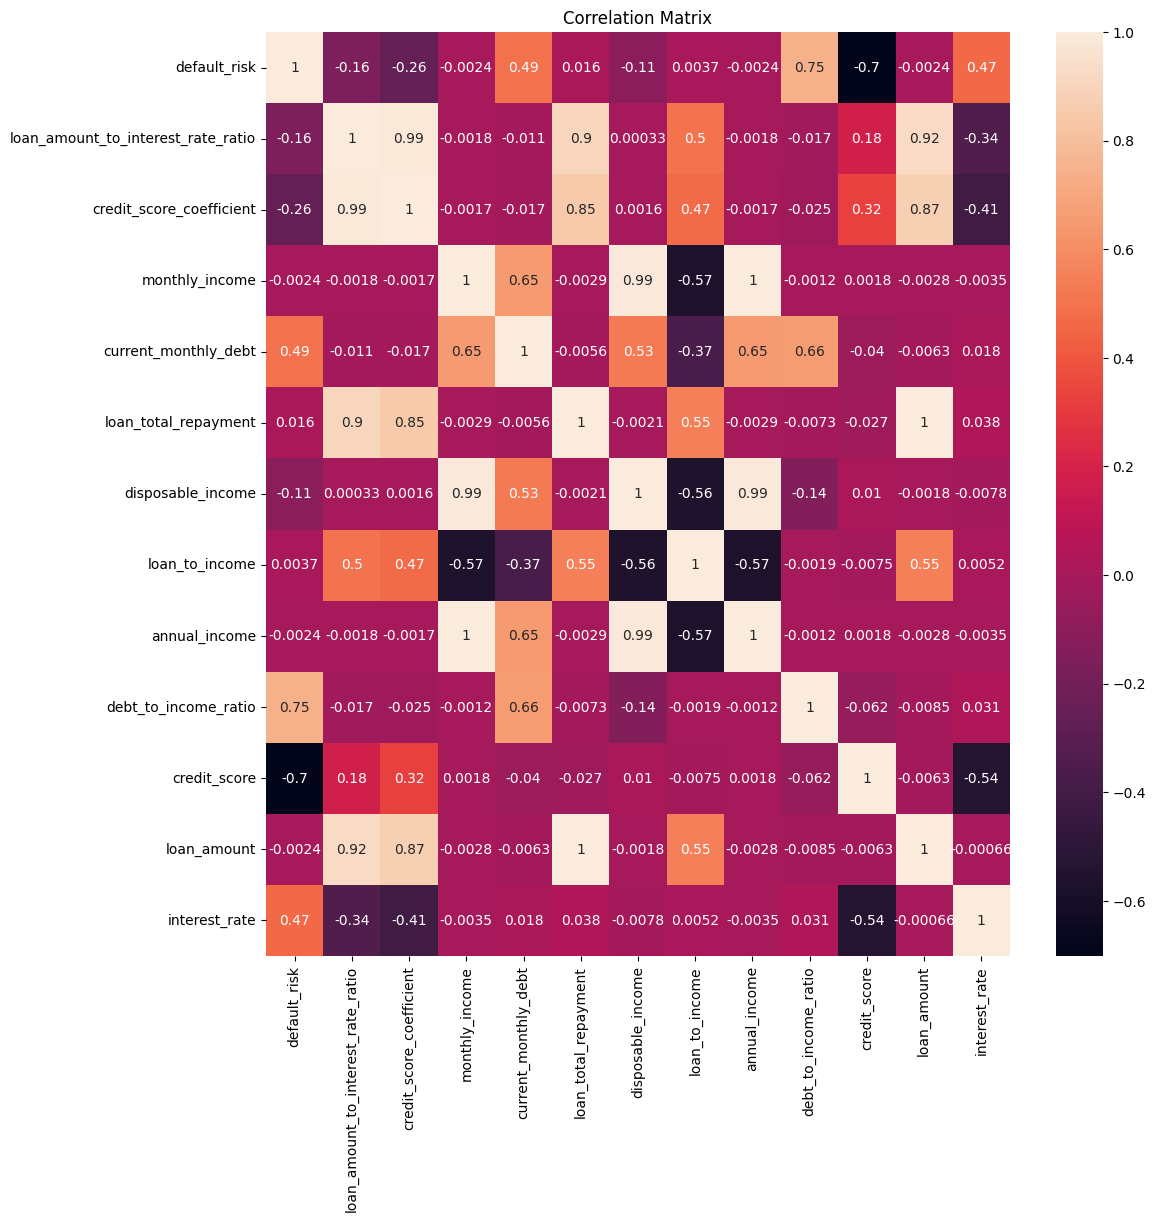

In [17]:
plt.figure(figsize = (12, 12))
corr_matrix = combined[new_columns + NUMS].corr()
sns.heatmap(corr_matrix, annot=True)

plt.title('Correlation Matrix')

plt.show()

In [18]:
corr_pairs = corr_matrix.stack().reset_index()
corr_pairs.columns = ['Att1', 'Att2', 'Corr']
corr_pairs = corr_pairs[corr_pairs['Att1'] < corr_pairs['Att2']]
high_corr_pairs = corr_pairs[corr_pairs['Corr'].abs() > 0.8]

high_corr_pairs

,Att1,Att2,Corr
18,loan_amount_to_interest_rate_ratio,loan_total_repayment,0.903634
27,credit_score_coefficient,loan_amount_to_interest_rate_ratio,0.985765
31,credit_score_coefficient,loan_total_repayment,0.853384
37,credit_score_coefficient,loan_amount,0.873399
81,disposable_income,monthly_income,0.987380
107,annual_income,monthly_income,1.000000
110,annual_income,disposable_income,0.987380
144,loan_amount,loan_amount_to_interest_rate_ratio,0.920559
148,loan_amount,loan_total_repayment,0.999090


In [19]:
cols_to_drop = ['loan_total_repayment', 'monthly_income', 'credit_score_coefficient', 'disposable_income']

combined = combined.drop(cols_to_drop, axis=1)

In [20]:
domain_columns = [col for col in new_columns if col not in cols_to_drop]
print(domain_columns)

['default_risk', 'loan_amount_to_interest_rate_ratio', 'current_monthly_debt', 'loan_to_income']


# Digits

In [21]:
digit_features = fe.make_deep_digits_features(combined, ['debt_to_income_ratio', 'interest_rate'])
combined = pd.concat([combined, digit_features], axis=1)

Remove constant columns

In [22]:
constant_columns = combined.columns[combined.nunique() == 1].tolist()
print(constant_columns)

['debt_to_income_ratio_int_digit_0']


In [23]:
combined = combined.drop(columns=constant_columns)

# Over/undersampling

In [24]:
density_ratio_features = fe.make_density_ratio_features(combined, original, CATS)
combined = pd.concat([combined, density_ratio_features], axis=1)

# Target encoding

In [25]:
columns_to_target_encode = CATS + qcut_features.columns.tolist() + uniform_cut_features.columns.tolist() + kmeans_cut_features.columns.tolist() + log_cut.columns.tolist()
pseudo_target_columns = ['TE_employment_status', 'debt_to_income_ratio', 'annual_income', 'interest_rate']
print(columns_to_target_encode)

['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'annual_income_quantile_binned', 'loan_amount_quantile_binned', 'annual_income_uniform_binned', 'loan_amount_uniform_binned', 'annual_income_kmeans_binned', 'loan_amount_kmeans_binned', 'annual_income_log_binned', 'loan_amount_log_binned']


In [26]:
combined = fe.mark_for_target_encoding(combined, columns_to_target_encode)
combined = fe.mark_as_pseudo_targets(combined, pseudo_target_columns)

In [27]:
combined.head()

,PT_annual_income,PT_debt_to_income_ratio,credit_score,loan_amount,PT_interest_rate,TE_gender,TE_marital_status,TE_education_level,PT_TE_employment_status,TE_loan_purpose,...,interest_rate_int_digit_1,interest_rate_dec_digit_0,interest_rate_dec_digit_1,interest_rate_dec_digit_2,gender_count_ratio,marital_status_count_ratio,education_level_count_ratio,employment_status_count_ratio,loan_purpose_count_ratio,grade_subgrade_count_ratio
id,,,,,,,,,,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,...,3,6,7,0,43.617202,45.679216,44.311370,25.666439,35.917255,55.551519
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,...,2,9,2,0,42.527055,44.154112,35.693609,49.500423,58.095226,45.665794
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,...,9,7,6,0,42.527055,45.679216,44.311370,49.500423,58.095226,53.511955
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,...,6,1,0,0,43.617202,45.679216,44.311370,49.500423,58.095226,25.420712
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,...,0,2,1,0,42.527055,44.154112,44.311370,49.500423,35.917255,45.670996


# Exporting processed data

In [28]:
X_processed = combined[combined['is_test'] == 0].drop(columns=['is_test']).copy()
test_processed = combined[combined['is_test'] == 1].drop(columns=['is_test']).copy()

X_processed = pd.concat([X_processed, y], axis=1)

In [33]:
cats = X_processed.select_dtypes(include=['object', 'string', 'category']).columns

for col in cats:
    X_processed[col] = X_processed[col].astype(str)
    X_processed[col] = X_processed[col].astype('category')
    test_processed[col] = test_processed[col].astype(str)
    test_processed[col] = test_processed[col].astype('category')

In [34]:
X_processed.to_parquet(f'../data/processed/FE_train.parquet')
test_processed.to_parquet(f'../data/processed/FE_test.parquet')